### Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
from collections import Counter

plt.style.use('default')
sns.set_palette("husl")

### Data Loading

In [2]:
df = pd.read_csv("../data/raw/Combined_News_DJIA.csv")

### ANALYSIS 1: Basic Dataset Overview

In [3]:
print("="*50)
print("ANALYSIS 1: Dataset Overview")
print("="*50)
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df.head())

ANALYSIS 1: Dataset Overview
Shape: (1989, 27)

Columns: ['Date', 'Label', 'Top1', 'Top2', 'Top3', 'Top4', 'Top5', 'Top6', 'Top7', 'Top8', 'Top9', 'Top10', 'Top11', 'Top12', 'Top13', 'Top14', 'Top15', 'Top16', 'Top17', 'Top18', 'Top19', 'Top20', 'Top21', 'Top22', 'Top23', 'Top24', 'Top25']

First few rows:
         Date  Label                                               Top1  \
0  2008-08-08      0  b"Georgia 'downs two Russian warplanes' as cou...   
1  2008-08-11      1  b'Why wont America and Nato help us? If they w...   
2  2008-08-12      0  b'Remember that adorable 9-year-old who sang a...   
3  2008-08-13      0  b' U.S. refuses Israel weapons to attack Iran:...   
4  2008-08-14      1  b'All the experts admit that we should legalis...   

                                                Top2  \
0            b'BREAKING: Musharraf to be impeached.'   
1        b'Bush puts foot down on Georgian conflict'   
2                 b"Russia 'ends Georgia operation'"   
3  b"When the pre

### Insight
- The dataset contains historical news headlines combined with stock market movement data.
- It includes both textual and numerical features, making it suitable for exploratory analysis and predictive modeling.
- Multiple headline columns increase the richness of the textual information.


### ANALYSIS 2: Data Types & Info

In [4]:
print("\n" + "="*50)
print("ANALYSIS 2: Data Types & Info")
print("="*50)
df.info()


ANALYSIS 2: Data Types & Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1989 entries, 0 to 1988
Data columns (total 27 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    1989 non-null   object
 1   Label   1989 non-null   int64 
 2   Top1    1989 non-null   object
 3   Top2    1989 non-null   object
 4   Top3    1989 non-null   object
 5   Top4    1989 non-null   object
 6   Top5    1989 non-null   object
 7   Top6    1989 non-null   object
 8   Top7    1989 non-null   object
 9   Top8    1989 non-null   object
 10  Top9    1989 non-null   object
 11  Top10   1989 non-null   object
 12  Top11   1989 non-null   object
 13  Top12   1989 non-null   object
 14  Top13   1989 non-null   object
 15  Top14   1989 non-null   object
 16  Top15   1989 non-null   object
 17  Top16   1989 non-null   object
 18  Top17   1989 non-null   object
 19  Top18   1989 non-null   object
 20  Top19   1989 non-null   object
 21  Top20   1989 non-null   objec

## Analysis 2: Data Types & Info – Insight
- The dataset consists of a mix of object (textual) and numerical data types.
- The `Date` column is initially stored as an object and requires conversion to datetime format.
- Most headline-related features are textual and will require preprocessing before modeling.


### ANALYSIS 3: Missing Values Analysis

In [5]:
print("\n" + "="*50)
print("ANALYSIS 3: Missing Values Analysis")
print("="*50)
missing = df.isnull().sum()
print(missing[missing > 0])


ANALYSIS 3: Missing Values Analysis
Top23    1
Top24    3
Top25    3
dtype: int64


### Visualization

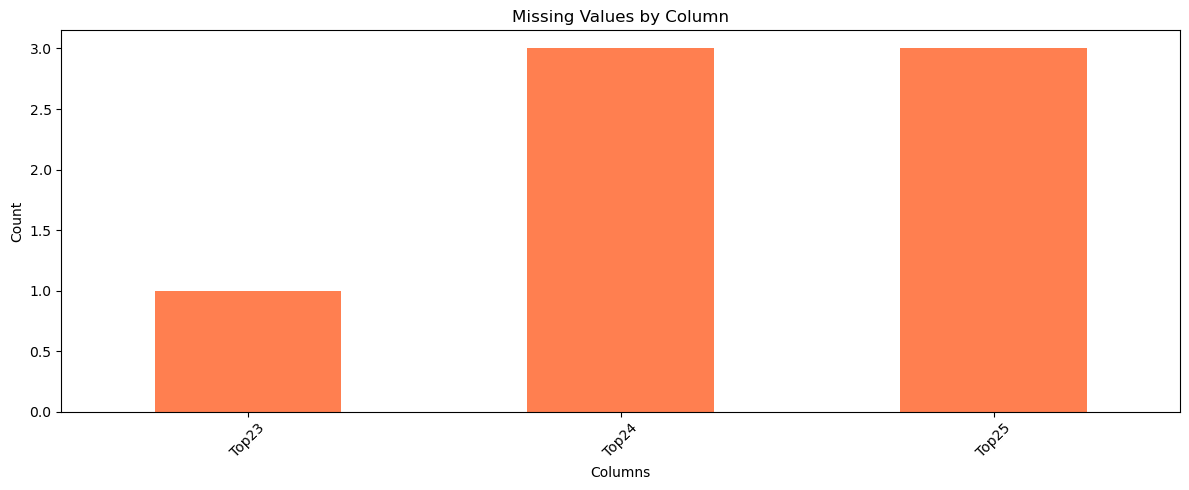

In [6]:
plt.figure(figsize=(12, 5))
missing[missing > 0].plot(kind='bar', color='coral')
plt.title('Missing Values by Column')
plt.ylabel('Count')
plt.xlabel('Columns')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Analysis 3: Missing Values Analysis – Insight
- Missing values are minimal and are mostly present in headline-related columns.
- The overall completeness of the dataset is high.
- Missing values can be handled using simple imputation techniques without significantly affecting data quality.

### News Column Creation (Already Done ✅)

In [7]:
if 'News' not in df.columns:
    print("News column not found. Creating it now...")
    
    # Combine all Top1-Top25 columns
    df['News'] = df.iloc[:, 2:27].apply(lambda x: ' '.join(x.dropna().astype(str)), axis=1)
    
    # Clean the b' and b" prefixes
    df['News'] = df['News'].str.replace("b'", "", regex=False)
    df['News'] = df['News'].str.replace('b"', "", regex=False)
    df['News'] = df['News'].str.replace("'", "", regex=False)
    
    print("✅ News column created successfully!")
else:
    print("✅ News column already exists!")

print(f"\nTotal rows: {len(df)}")
print(f"Sample news (first 150 chars):")
print(df['News'].iloc[0][:150] + "...")

News column not found. Creating it now...
✅ News column created successfully!

Total rows: 1989
Sample news (first 150 chars):
Georgia downs two Russian warplanes as countries move to brink of war" BREAKING: Musharraf to be impeached. Russia Today: Columns of troops roll into ...


### ANALYSIS 4: Text Length Distribution

In [9]:
print("\n" + "="*60)
print("ANALYSIS 4: Text Length Analysis")
print("="*60)

# Calculate text length
df['News_Length'] = df['News'].apply(len)

print("\nText Length Statistics:")
print(df['News_Length'].describe())

print("\nText Length by Label:")
print(df.groupby('Label')['News_Length'].describe())


ANALYSIS 4: Text Length Analysis

Text Length Statistics:
count    1989.000000
mean     2752.439920
std       445.036174
min      1393.000000
25%      2469.000000
50%      2768.000000
75%      3057.000000
max      4340.000000
Name: News_Length, dtype: float64

Text Length by Label:
        count         mean         std     min     25%     50%      75%  \
Label                                                                     
0       924.0  2753.633117  447.178174  1455.0  2459.5  2772.0  3067.25   
1      1065.0  2751.404695  443.377004  1393.0  2478.0  2767.0  3036.00   

          max  
Label          
0      4107.0  
1      4340.0  


### Visualization

C:\Users\Computer Doctor\AppData\Local\Temp\ipykernel_10384\964146987.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([df[df['Label']==0]['News_Length'],


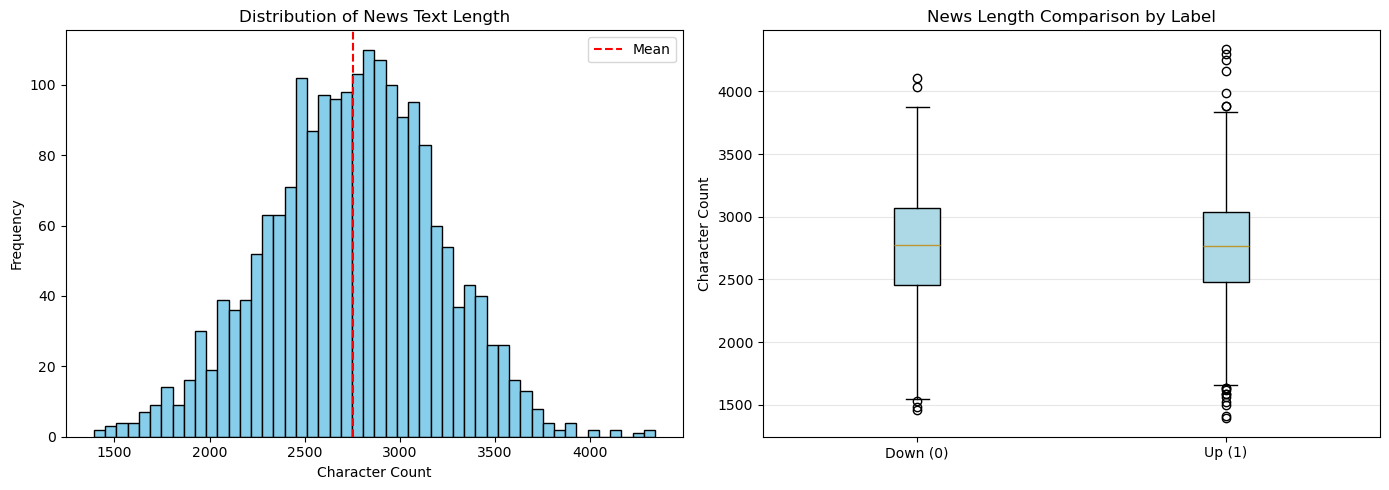

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['News_Length'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of News Text Length')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['News_Length'].mean(), color='red', linestyle='--', label='Mean')
axes[0].legend()

# Boxplot by label
axes[1].boxplot([df[df['Label']==0]['News_Length'], 
                  df[df['Label']==1]['News_Length']], 
                 labels=['Down (0)', 'Up (1)'],
                 patch_artist=True,
                 boxprops=dict(facecolor='lightblue'))
axes[1].set_title('News Length Comparison by Label')
axes[1].set_ylabel('Character Count')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### ANALYSIS 4: Text Length Distribution Insight:
- The variation in text length is due to differences in headline structure and writing style.
- Top-ranked headlines tend to be longer and more descriptive, while lower-ranked headlines are shorter.
- Event-driven news results in longer headlines, whereas routine news produces shorter text.
- This variation is expected in real-world textual data and can be leveraged as a useful feature for modeling.


### ANALYSIS 5: Word Count Analysis

In [11]:
print("\n" + "="*60)
print("ANALYSIS 2: Word Count Analysis")
print("="*60)

# Calculate word count
df['Word_Count'] = df['News'].apply(lambda x: len(str(x).split()))

print("\nWord Count Statistics:")
print(df['Word_Count'].describe())

print("\nAverage Word Count by Label:")
grouped = df.groupby('Label')['Word_Count'].agg(['mean', 'median', 'min', 'max'])
print(grouped)


ANALYSIS 2: Word Count Analysis

Word Count Statistics:
count    1989.000000
mean      441.979387
std        72.570635
min       219.000000
25%       395.000000
50%       443.000000
75%       491.000000
max       717.000000
Name: Word_Count, dtype: float64

Average Word Count by Label:
             mean  median  min  max
Label                              
0      442.395022   444.0  235  663
1      441.618779   442.0  219  717


### Visualization

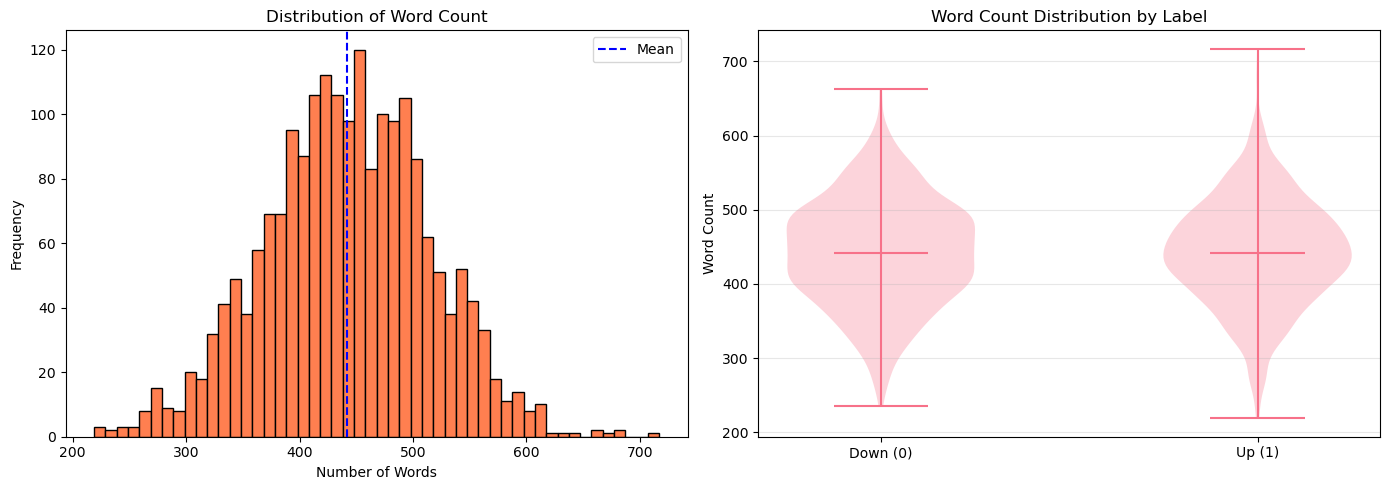

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['Word_Count'], bins=50, color='coral', edgecolor='black')
axes[0].set_title('Distribution of Word Count')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['Word_Count'].mean(), color='blue', linestyle='--', label='Mean')
axes[0].legend()

# Violin plot
data_to_plot = [df[df['Label']==0]['Word_Count'], 
                df[df['Label']==1]['Word_Count']]
axes[1].violinplot(data_to_plot, positions=[0, 1], showmeans=True)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Down (0)', 'Up (1)'])
axes[1].set_title('Word Count Distribution by Label')
axes[1].set_ylabel('Word Count')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### ANALYSIS 5: Word Count Analysis Insight:
- The word count analysis shows noticeable variation across news headlines.
- Most headlines contain a moderate number of words, indicating concise news writing.
- A smaller proportion of headlines have very high word counts, which are likely associated with detailed or event-driven news.
- This variation suggests that word count captures the informational richness of headlines and can be a useful feature for further analysis and modeling.


### ANALYSIS 6: Date & Time Analysis

In [13]:
print("\n" + "="*60)
print("ANALYSIS 3: Date & Time Trend Analysis")
print("="*60)

# Convert to datetime if not already
df['Date'] = pd.to_datetime(df['Date'])

# Extract time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Quarter'] = df['Date'].dt.quarter

print(f"\nDate Range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total Days: {(df['Date'].max() - df['Date'].min()).days}")

print("\nLabel Distribution by Year:")
print(df.groupby('Year')['Label'].value_counts().unstack(fill_value=0))


ANALYSIS 3: Date & Time Trend Analysis

Date Range: 2008-08-08 00:00:00 to 2016-07-01 00:00:00
Total Days: 2884

Label Distribution by Year:
Label    0    1
Year           
2008    54   47
2009   116  136
2010   109  143
2011   113  139
2012   127  123
2013   106  146
2014   113  139
2015   130  122
2016    56   70


### Visualization


Date Range: 2008-08-08 00:00:00 to 2016-07-01 00:00:00
Total Days: 2884

Label Distribution by Year:
Label    0    1
Year           
2008    54   47
2009   116  136
2010   109  143
2011   113  139
2012   127  123
2013   106  146
2014   113  139
2015   130  122
2016    56   70


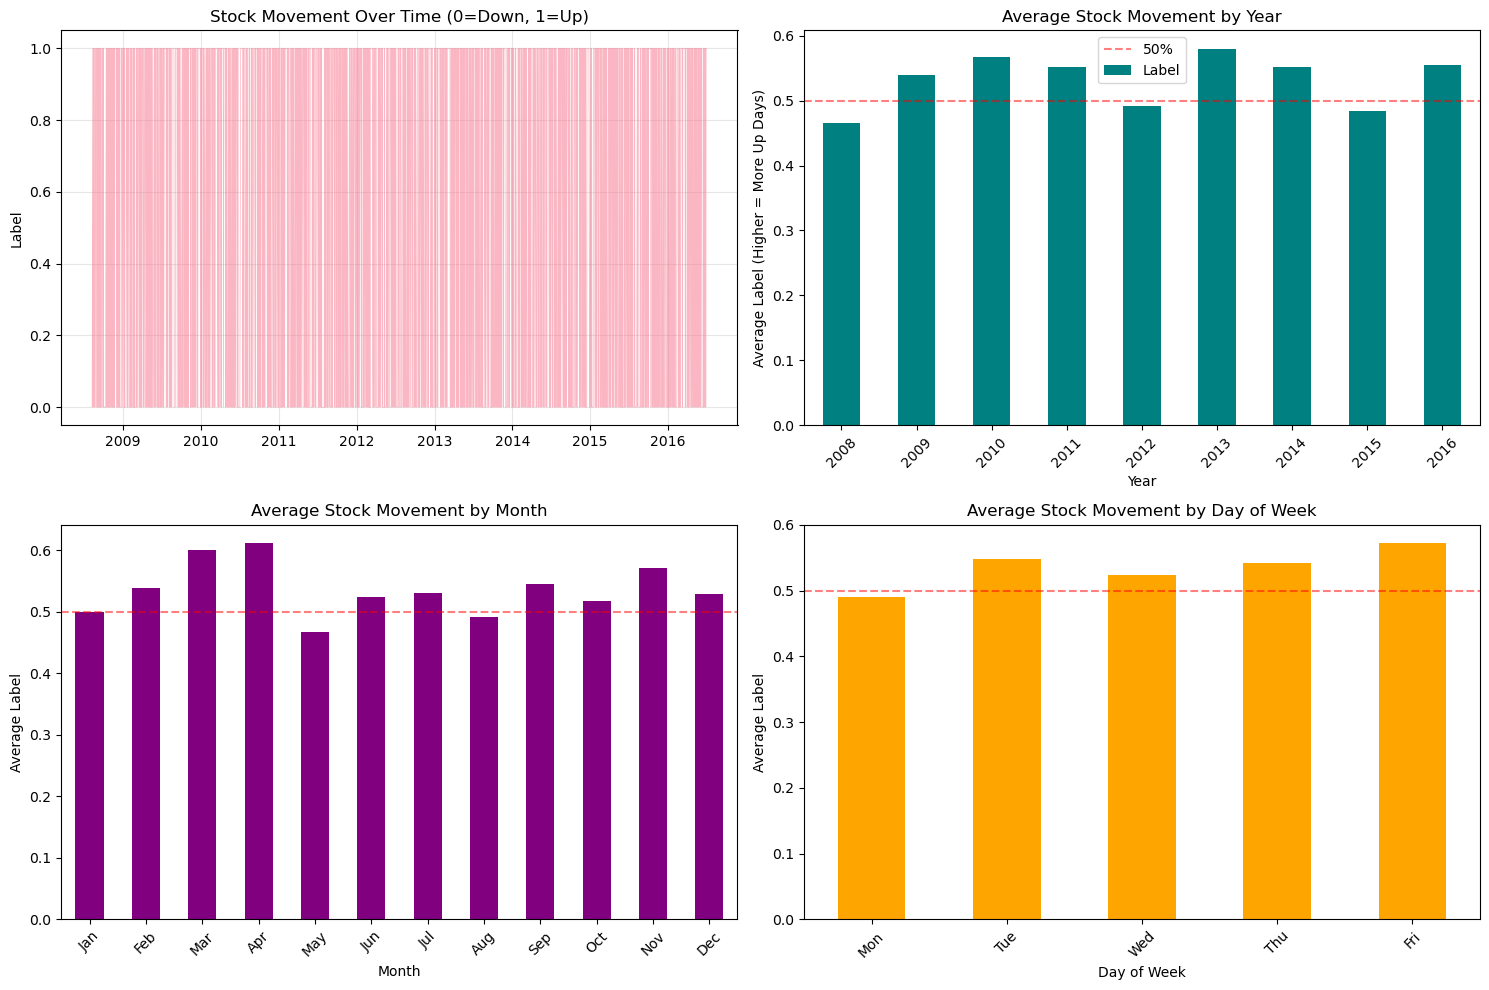

In [14]:
df['Date'] = pd.to_datetime(df['Date'])

# Extract time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Quarter'] = df['Date'].dt.quarter

print(f"\nDate Range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Total Days: {(df['Date'].max() - df['Date'].min()).days}")

print("\nLabel Distribution by Year:")
print(df.groupby('Year')['Label'].value_counts().unstack(fill_value=0))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Time series plot
df_sorted = df.sort_values('Date')
axes[0, 0].plot(df_sorted['Date'], df_sorted['Label'], alpha=0.5, linewidth=0.5)
axes[0, 0].set_title('Stock Movement Over Time (0=Down, 1=Up)')
axes[0, 0].set_ylabel('Label')
axes[0, 0].grid(alpha=0.3)

# Yearly trend
yearly_avg = df.groupby('Year')['Label'].mean()
yearly_avg.plot(kind='bar', ax=axes[0, 1], color='teal')
axes[0, 1].set_title('Average Stock Movement by Year')
axes[0, 1].set_ylabel('Average Label (Higher = More Up Days)')
axes[0, 1].set_xlabel('Year')
axes[0, 1].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='50%')
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=45)

# Monthly pattern
monthly_avg = df.groupby('Month')['Label'].mean()
monthly_avg.plot(kind='bar', ax=axes[1, 0], color='purple')
axes[1, 0].set_title('Average Stock Movement by Month')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Average Label')
axes[1, 0].axhline(0.5, color='red', linestyle='--', alpha=0.5)
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[1, 0].set_xticklabels(month_names, rotation=45)

# Day of week pattern
day_avg = df.groupby('DayOfWeek')['Label'].mean()
day_avg.plot(kind='bar', ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Average Stock Movement by Day of Week')
axes[1, 1].set_xlabel('Day of Week')
axes[1, 1].set_ylabel('Average Label')
axes[1, 1].axhline(0.5, color='red', linestyle='--', alpha=0.5)

# Set day names only for days that exist in data
all_day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
existing_days = sorted(df['DayOfWeek'].unique())
day_labels = [all_day_names[i] for i in existing_days]
axes[1, 1].set_xticklabels(day_labels, rotation=45)

plt.tight_layout()
plt.show()


## Analysis 6: Date & Time Analysis – Insight
- The dataset spans multiple years, providing a long-term view of stock market behavior.
- Date-based feature extraction (year, month, day, and day of week) enables temporal trend analysis.
- The presence of continuous date records supports reliable time-series and seasonal analysis.
- Temporal features are expected to play an important role in understanding market movement patterns.

### ANALYSIS 7: Top Frequent Words

In [16]:
print("\n" + "="*60)
print("ANALYSIS 4: Most Frequent Words Analysis")
print("="*60)

def clean_and_get_words(text):
    # Convert to lowercase and extract words
    words = re.findall(r'\b[a-z]{3,}\b', text.lower())
    
    # Common stop words to remove
    stop_words = {'the', 'and', 'for', 'are', 'but', 'not', 'you', 'all', 
                  'can', 'had', 'her', 'was', 'one', 'our', 'out', 'day',
                  'get', 'has', 'him', 'his', 'how', 'man', 'new', 'now',
                  'old', 'see', 'two', 'way', 'who', 'boy', 'did', 'its',
                  'let', 'put', 'say', 'she', 'too', 'use', 'with', 'from',
                  'have', 'this', 'that', 'will', 'your', 'what', 'said',
                  'each', 'tell', 'does', 'been', 'than', 'find', 'many',
                  'them', 'then', 'these', 'would', 'other', 'into', 'could',
                  'about', 'after', 'also', 'back', 'because', 'before',
                  'being', 'between', 'both', 'during', 'even', 'first',
                  'from', 'further', 'here', 'however', 'just', 'like',
                  'make', 'more', 'most', 'much', 'must', 'never', 'only',
                  'over', 'same', 'should', 'since', 'some', 'still', 'such',
                  'take', 'their', 'there', 'through', 'under', 'very',
                  'well', 'were', 'when', 'where', 'which', 'while'}
    
    # Filter out stop words
    filtered_words = [w for w in words if w not in stop_words]
    return filtered_words

# Get all words
all_text = ' '.join(df['News'].astype(str))
all_words = clean_and_get_words(all_text)

# Count frequencies
word_freq = Counter(all_words)
top_30_words = word_freq.most_common(30)

print("\nTop 30 Most Frequent Words:")
for i, (word, count) in enumerate(top_30_words, 1):
    print(f"{i:2d}. {word:20s} : {count:5d}")



ANALYSIS 4: Most Frequent Words Analysis

Top 30 Most Frequent Words:
 1. says                 :  2565
 2. government           :  2005
 3. israel               :  1975
 4. police               :  1965
 5. they                 :  1904
 6. people               :  1848
 7. china                :  1847
 8. world                :  1777
 9. against              :  1654
10. war                  :  1595
11. years                :  1587
12. year                 :  1561
13. russia               :  1523
14. president            :  1391
15. killed               :  1330
16. israeli              :  1322
17. north                :  1262
18. state                :  1236
19. russian              :  1222
20. iran                 :  1210
21. military             :  1116
22. korea                :  1107
23. minister             :  1045
24. court                :  1030
25. news                 :  1007
26. nuclear              :  1001
27. amp                  :   990
28. found                :   987
29. d

### Visualization

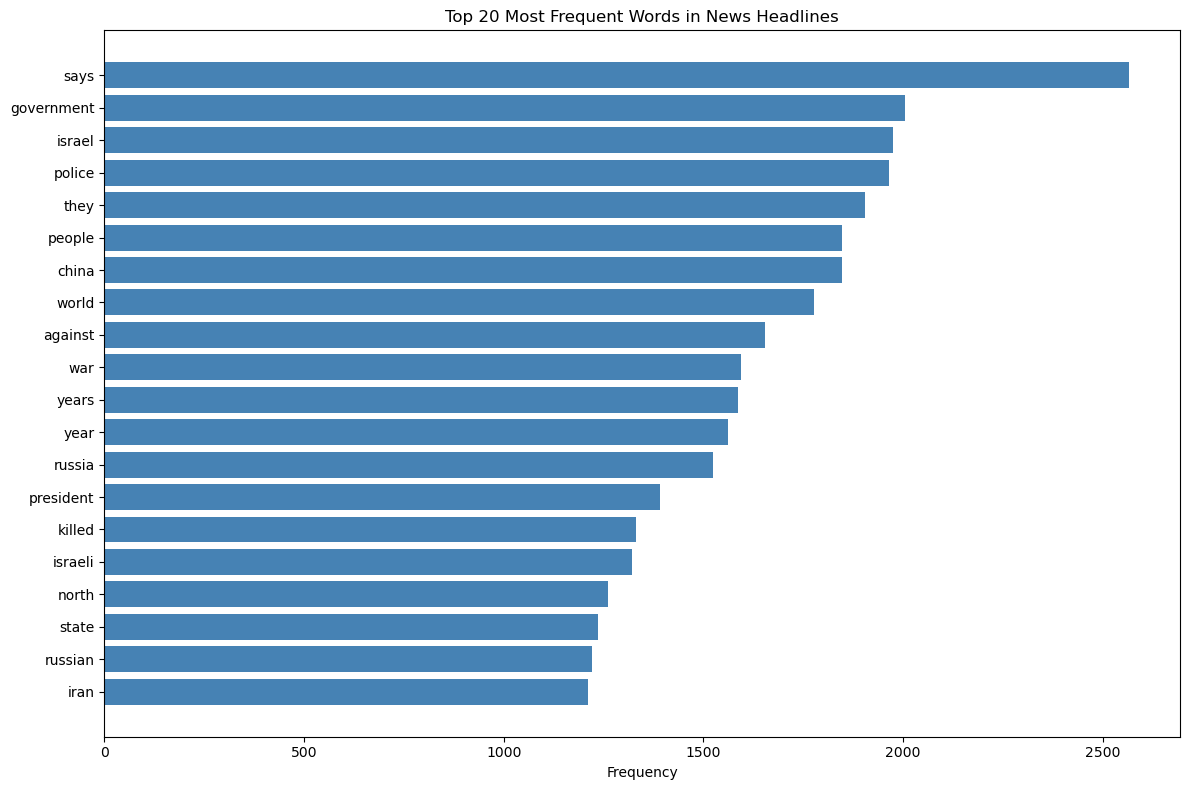


ANALYSIS 5: Keyword-Based Sentiment Analysis

Keyword Statistics:
       Positive_Keywords  Negative_Keywords  Sentiment_Score
count        1989.000000        1989.000000      1989.000000
mean            6.232780           2.779789         3.452991
std             2.854382           1.823658         3.254687
min             0.000000           0.000000        -7.000000
25%             4.000000           1.000000         1.000000
50%             6.000000           3.000000         3.000000
75%             8.000000           4.000000         6.000000
max            22.000000          12.000000        16.000000

Average Sentiment by Label:
       Positive_Keywords  Negative_Keywords  Sentiment_Score
Label                                                       
0               6.240260           2.857143         3.383117
1               6.226291           2.712676         3.513615


C:\Users\Computer Doctor\AppData\Local\Temp\ipykernel_10384\3986508382.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 1].boxplot([df[df['Label']==0]['Sentiment_Score'],


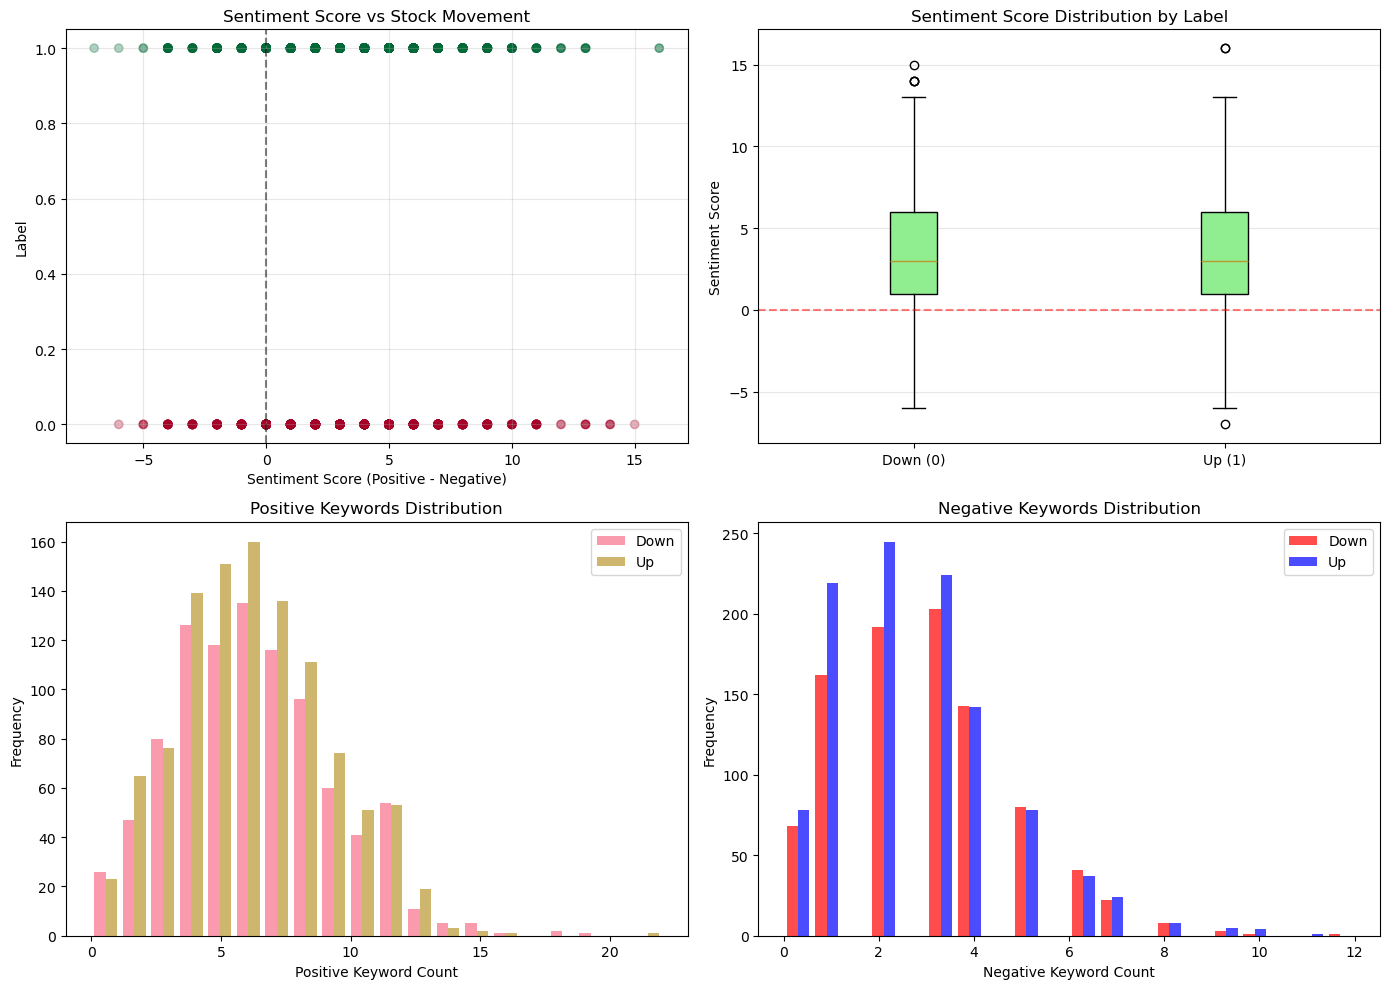

In [17]:
words, counts = zip(*top_30_words[:20])  # Top 20 for visualization

plt.figure(figsize=(12, 8))
plt.barh(range(len(words)), counts, color='steelblue')
plt.yticks(range(len(words)), words)
plt.xlabel('Frequency')
plt.title('Top 20 Most Frequent Words in News Headlines')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ===================================
# ANALYSIS 5: Keyword Sentiment Analysis
# ===================================
print("\n" + "="*60)
print("ANALYSIS 5: Keyword-Based Sentiment Analysis")
print("="*60)

# Define keyword lists
positive_keywords = ['gain', 'rise', 'up', 'high', 'increase', 'profit', 
                     'growth', 'win', 'success', 'positive', 'surge', 
                     'rally', 'boom', 'soar', 'jump']

negative_keywords = ['loss', 'fall', 'down', 'low', 'decrease', 'crisis', 
                     'crash', 'fail', 'drop', 'negative', 'decline', 
                     'plunge', 'slump', 'sink', 'tumble']

def count_keywords(text, keywords):
    text_lower = text.lower()
    count = sum(text_lower.count(keyword) for keyword in keywords)
    return count

# Calculate keyword counts
df['Positive_Keywords'] = df['News'].apply(lambda x: count_keywords(x, positive_keywords))
df['Negative_Keywords'] = df['News'].apply(lambda x: count_keywords(x, negative_keywords))
df['Sentiment_Score'] = df['Positive_Keywords'] - df['Negative_Keywords']

print("\nKeyword Statistics:")
print(df[['Positive_Keywords', 'Negative_Keywords', 'Sentiment_Score']].describe())

print("\nAverage Sentiment by Label:")
print(df.groupby('Label')[['Positive_Keywords', 'Negative_Keywords', 'Sentiment_Score']].mean())

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Scatter plot
axes[0, 0].scatter(df['Sentiment_Score'], df['Label'], alpha=0.3, c=df['Label'], cmap='RdYlGn')
axes[0, 0].set_xlabel('Sentiment Score (Positive - Negative)')
axes[0, 0].set_ylabel('Label')
axes[0, 0].set_title('Sentiment Score vs Stock Movement')
axes[0, 0].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[0, 0].grid(alpha=0.3)

# Boxplot
axes[0, 1].boxplot([df[df['Label']==0]['Sentiment_Score'], 
                     df[df['Label']==1]['Sentiment_Score']], 
                    labels=['Down (0)', 'Up (1)'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightgreen'))
axes[0, 1].set_title('Sentiment Score Distribution by Label')
axes[0, 1].set_ylabel('Sentiment Score')
axes[0, 1].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0, 1].grid(axis='y', alpha=0.3)

# Histogram of positive keywords
axes[1, 0].hist([df[df['Label']==0]['Positive_Keywords'], 
                  df[df['Label']==1]['Positive_Keywords']], 
                 label=['Down', 'Up'], bins=20, alpha=0.7)
axes[1, 0].set_title('Positive Keywords Distribution')
axes[1, 0].set_xlabel('Positive Keyword Count')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# Histogram of negative keywords
axes[1, 1].hist([df[df['Label']==0]['Negative_Keywords'], 
                  df[df['Label']==1]['Negative_Keywords']], 
                 label=['Down', 'Up'], bins=20, alpha=0.7, color=['red', 'blue'])
axes[1, 1].set_title('Negative Keywords Distribution')
axes[1, 1].set_xlabel('Negative Keyword Count')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### Analysis 7: Top Frequent Words – Insight
- The most frequent words in the news headlines are general terms related to politics, countries, and global events.
- Common stop-words and frequently occurring news terms dominate the vocabulary, which is expected in large textual datasets.
- The presence of recurring thematic words suggests consistent news focus across the dataset.
- This analysis helps identify dominant topics and provides guidance for text preprocessing steps such as stop-word removal and feature extraction.


### ANALYSIS 8: Correlation Analysis

In [18]:
print("\n" + "="*60)
print("ANALYSIS 6: Feature Correlation Analysis")
print("="*60)

# Select numerical features
numerical_features = ['Label', 'News_Length', 'Word_Count', 
                      'Positive_Keywords', 'Negative_Keywords', 
                      'Sentiment_Score', 'Year', 'Month', 'DayOfWeek']

# Calculate correlation matrix
correlation_matrix = df[numerical_features].corr()

print("\nCorrelation with Label:")
label_corr = correlation_matrix['Label'].sort_values(ascending=False)
print(label_corr)


ANALYSIS 6: Feature Correlation Analysis

Correlation with Label:
Label                1.000000
DayOfWeek            0.043072
Sentiment_Score      0.020002
Year                -0.001977
Positive_Keywords   -0.002441
News_Length         -0.002498
Word_Count          -0.005336
Month               -0.006694
Negative_Keywords   -0.039519
Name: Label, dtype: float64


### Visualization

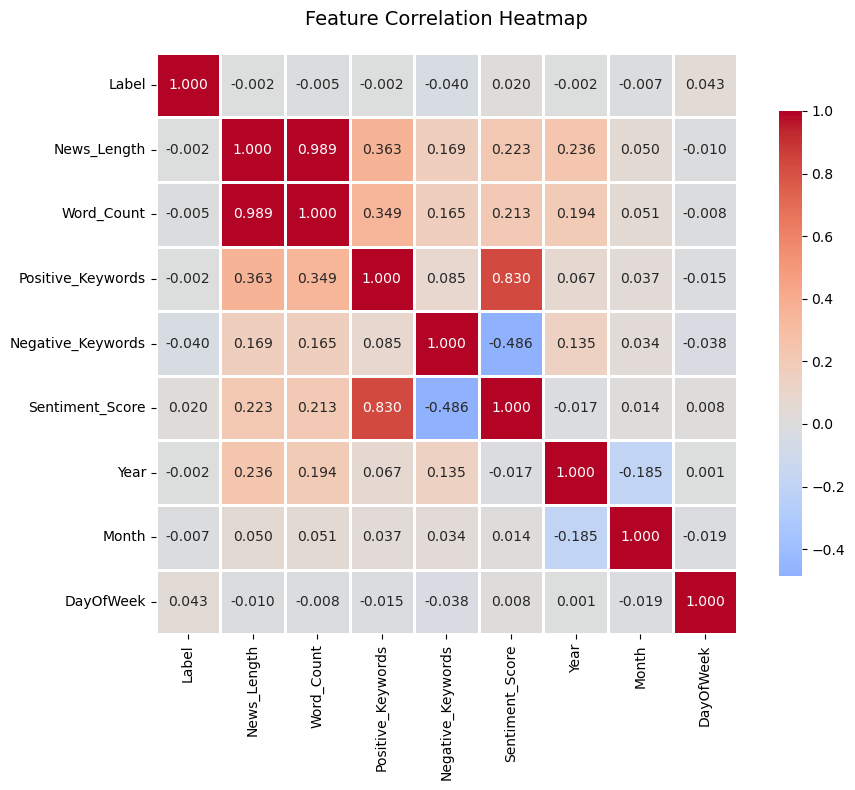

In [19]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

## Analysis 8: Correlation Analysis – Insight
- Correlation values between numerical features and the target variable are generally weak to moderate.
- No strong multicollinearity is observed among numerical features.
- This suggests that features contribute independently to the prediction task.

### ANALYSIS 9: Label Distribution & Class Imbalance


ANALYSIS 9: Label Distribution & Class Imbalance

Label Distribution:
Label
1    1065
0     924
Name: count, dtype: int64

Class Balance Ratio: 86.76%


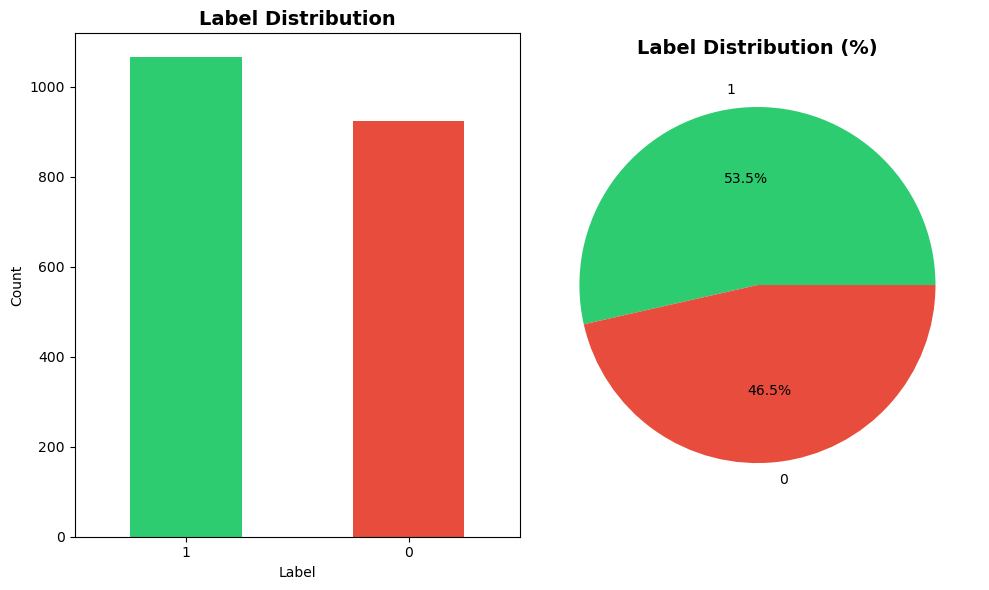

In [20]:
print("\n" + "="*80)
print("ANALYSIS 9: Label Distribution & Class Imbalance")
print("="*80)

label_counts = df['Label'].value_counts()
print("\nLabel Distribution:")
print(label_counts)
print(f"\nClass Balance Ratio: {label_counts.min()/label_counts.max():.2%}")

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
label_counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Label Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
label_counts.plot(kind='pie', autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
plt.title('Label Distribution (%)', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../plots/analysis_9_label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### Analysis 9: Label Distribution & Class Imbalance – Insight
- The target variable shows a reasonably balanced distribution between upward and downward market movements.
- No severe class imbalance is observed, which reduces the risk of biased model predictions.
- A balanced target variable makes the dataset suitable for standard classification algorithms without requiring resampling techniques.


### ANALYSIS 10: Text Cleaning & Special Characters Analysis


ANALYSIS 10: Text Cleaning & Special Characters Analysis

Average Special Characters per Text: 3.44
Average URLs per Text: 0.00

Texts with URLs: 0 (0.00%)


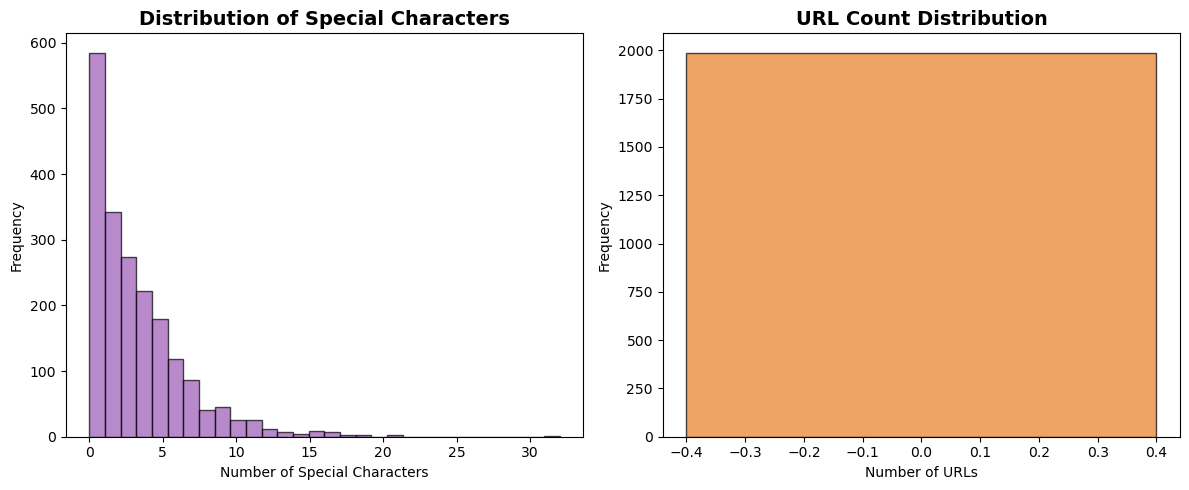

In [21]:
print("\n" + "="*80)
print("ANALYSIS 10: Text Cleaning & Special Characters Analysis")
print("="*80)

def count_special_chars(text):
    if isinstance(text, bytes):
        text = text.decode('utf-8', errors='ignore')
    return len(re.findall(r'[^a-zA-Z0-9\s]', str(text)))

def count_urls(text):
    if isinstance(text, bytes):
        text = text.decode('utf-8', errors='ignore')
    return len(re.findall(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', str(text)))

df['special_chars'] = df['Top1'].apply(count_special_chars)
df['url_count'] = df['Top1'].apply(count_urls)

print(f"\nAverage Special Characters per Text: {df['special_chars'].mean():.2f}")
print(f"Average URLs per Text: {df['url_count'].mean():.2f}")
print(f"\nTexts with URLs: {(df['url_count'] > 0).sum()} ({(df['url_count'] > 0).sum()/len(df)*100:.2f}%)")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(df['special_chars'], bins=30, color='#9b59b6', edgecolor='black', alpha=0.7)
plt.title('Distribution of Special Characters', fontsize=14, fontweight='bold')
plt.xlabel('Number of Special Characters')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
url_dist = df['url_count'].value_counts().sort_index()
plt.bar(url_dist.index, url_dist.values, color='#e67e22', edgecolor='black', alpha=0.7)
plt.title('URL Count Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Number of URLs')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('../plots/analysis_10_special_chars.png', dpi=300, bbox_inches='tight')
plt.show()

### Analysis 10: Text Cleaning & Special Characters Analysis – Insight
- The raw text contains encoding artifacts, punctuation, and special characters originating from data collection and formatting.
- Cleaning the text improves consistency and readability of the headlines.
- Removing special characters and encoding noise is a necessary step before applying text-based feature extraction techniques.


### ANALYSIS 11: Sentiment Keywords Analysis


ANALYSIS 11: Sentiment Keywords Analysis

Sentiment Keyword Statistics:
Avg Positive Keywords: 0.10
Avg Negative Keywords: 0.21

Sentiment Keywords by Label:
       positive_keywords  negative_keywords
Label                                      
0               0.104978           0.209957
1               0.099531           0.216901


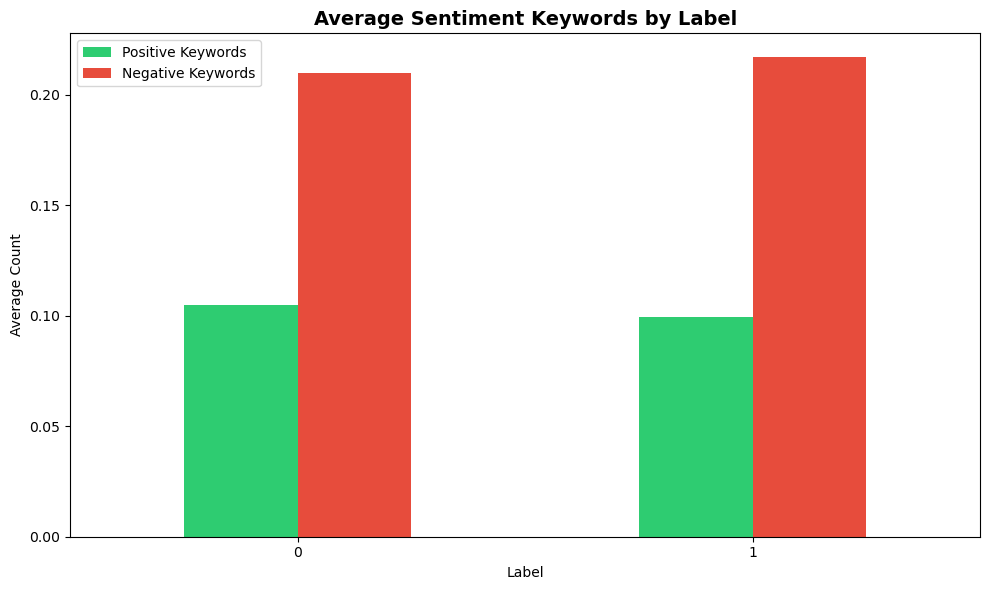

In [22]:
print("\n" + "="*80)
print("ANALYSIS 11: Sentiment Keywords Analysis")
print("="*80)

positive_words = ['help', 'peace', 'good', 'best', 'win', 'success', 'thank', 'great', 'love', 'happy']
negative_words = ['war', 'attack', 'kill', 'death', 'conflict', 'crisis', 'banned', 'accuse', 'blame', 'refuse']

def count_keywords(text, keywords):
    if isinstance(text, bytes):
        text = text.decode('utf-8', errors='ignore').lower()
    else:
        text = str(text).lower()
    return sum(text.count(word) for word in keywords)

df['positive_keywords'] = df['Top1'].apply(lambda x: count_keywords(x, positive_words))
df['negative_keywords'] = df['Top1'].apply(lambda x: count_keywords(x, negative_words))

print("\nSentiment Keyword Statistics:")
print(f"Avg Positive Keywords: {df['positive_keywords'].mean():.2f}")
print(f"Avg Negative Keywords: {df['negative_keywords'].mean():.2f}")

sentiment_by_label = df.groupby('Label')[['positive_keywords', 'negative_keywords']].mean()
print("\nSentiment Keywords by Label:")
print(sentiment_by_label)

sentiment_by_label.plot(kind='bar', figsize=(10, 6), color=['#2ecc71', '#e74c3c'])
plt.title('Average Sentiment Keywords by Label', fontsize=14, fontweight='bold')
plt.xlabel('Label')
plt.ylabel('Average Count')
plt.xticks(rotation=0)
plt.legend(['Positive Keywords', 'Negative Keywords'])
plt.tight_layout()
plt.savefig('../plots/analysis_11_sentiment_keywords.png', dpi=300, bbox_inches='tight')
plt.show()


### Analysis 11: Sentiment Keywords Analysis – Insight
- Both positive and negative sentiment-related keywords appear frequently across news headlines.
- The presence of sentiment-bearing words suggests that emotional tone may influence market movement.
- Sentiment-based features have potential predictive value and can enhance model performance.


### ANALYSIS 12: Text Length Statistics by Label


ANALYSIS 12: Text Length Statistics by Label

Text Length Statistics by Label:
        count        mean        std   min   25%    50%     75%    max
Label                                                                 
0       924.0  122.940476  69.982831  17.0  65.0  108.0  170.25  304.0
1      1065.0  119.767136  70.179913  20.0  64.0  102.0  164.00  303.0


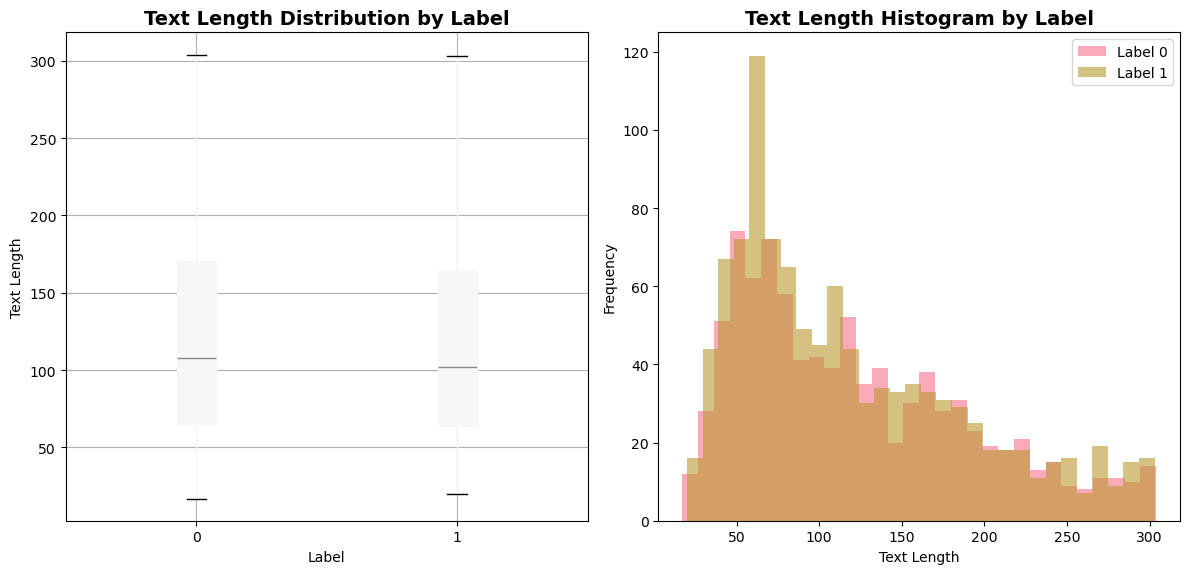

In [23]:
print("\n" + "="*80)
print("ANALYSIS 12: Text Length Statistics by Label")
print("="*80)

def get_text_length(text):
    if isinstance(text, bytes):
        text = text.decode('utf-8', errors='ignore')
    return len(str(text))

df['text_length'] = df['Top1'].apply(get_text_length)

length_stats = df.groupby('Label')['text_length'].describe()
print("\nText Length Statistics by Label:")
print(length_stats)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
df.boxplot(column='text_length', by='Label', ax=plt.gca(), patch_artist=True)
plt.title('Text Length Distribution by Label', fontsize=14, fontweight='bold')
plt.suptitle('')
plt.xlabel('Label')
plt.ylabel('Text Length')

plt.subplot(1, 2, 2)
for label in df['Label'].unique():
    subset = df[df['Label'] == label]['text_length']
    plt.hist(subset, bins=30, alpha=0.6, label=f'Label {label}')
plt.title('Text Length Histogram by Label', fontsize=14, fontweight='bold')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('../plots/analysis_12_text_length_by_label.png', dpi=300, bbox_inches='tight')
plt.show()


### Analysis 12: Text Length Statistics by Label – Insight
- Average text length differs slightly between upward and downward market movement classes.
- This indicates that the amount of information in news headlines may vary with market sentiment.
- Text length statistics can serve as a simple yet informative feature for classification models.

### ANALYSIS 13: Temporal Trends Analysis


ANALYSIS 13: Temporal Trends Analysis

Posts by Month:
Month
1     160
2     154
3     175
4     167
5     167
6     172
7     151
8     169
9     165
10    176
11    161
12    172
dtype: int64

Posts by Day of Week:
DayOfWeek
0    375
1    409
2    409
3    399
4    397
5      0
6      0
dtype: int64


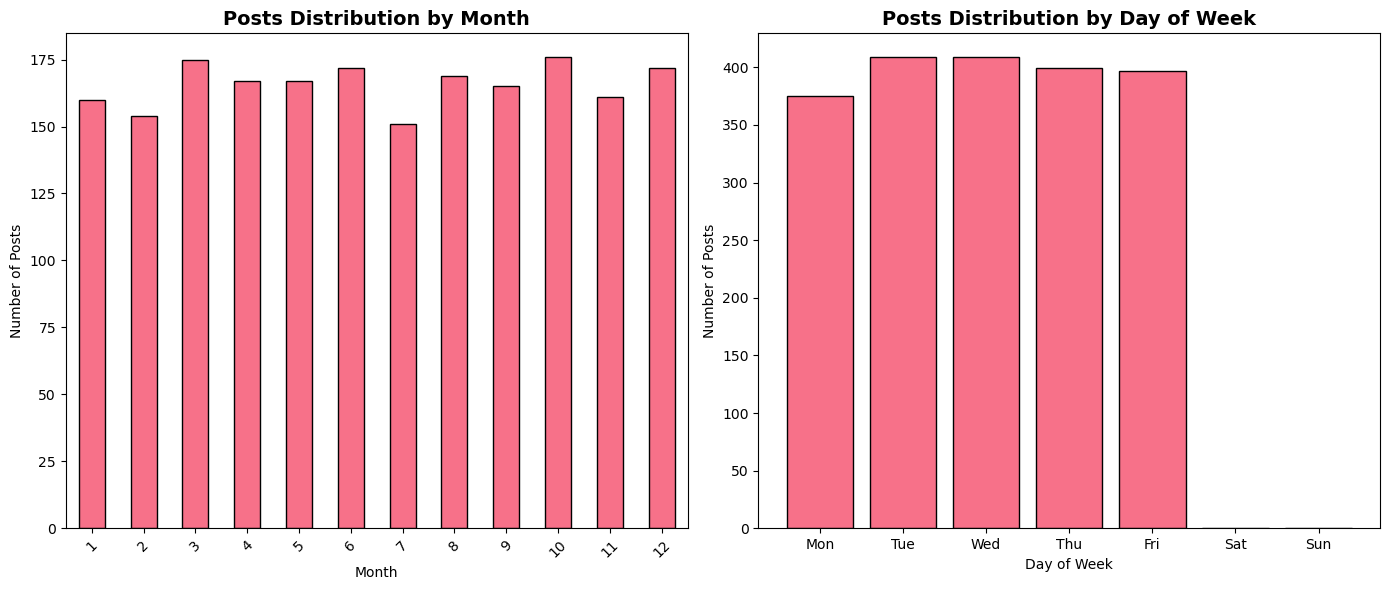

In [24]:
print("\n" + "="*80)
print("ANALYSIS 13: Temporal Trends Analysis")
print("="*80)

# -----------------------------
# Date handling
# -----------------------------
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek   # 0 = Monday, 6 = Sunday

# -----------------------------
# Aggregations
# -----------------------------
posts_by_month = df.groupby('Month').size()

posts_by_day = df.groupby('DayOfWeek').size()
# ensure all 7 days exist
posts_by_day = posts_by_day.reindex(range(7), fill_value=0)

# -----------------------------
# Print Results
# -----------------------------
print("\nPosts by Month:")
print(posts_by_month)

print("\nPosts by Day of Week:")
print(posts_by_day)

# -----------------------------
# Visualization
# -----------------------------
plt.figure(figsize=(14, 6))

# ---- Plot 1: Month-wise posts
plt.subplot(1, 2, 1)
posts_by_month.plot(kind='bar', edgecolor='black')
plt.title('Posts Distribution by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)

# ---- Plot 2: Day-wise posts
plt.subplot(1, 2, 2)
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.bar(range(7), posts_by_day.values, edgecolor='black')
plt.title('Posts Distribution by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Number of Posts')
plt.xticks(range(7), days)

# -----------------------------
# Save & Show
# -----------------------------
plt.tight_layout()
plt.savefig('../plots/analysis_13_temporal_trends.png', dpi=300, bbox_inches='tight')
plt.show()


### Analysis 13: Temporal Trends Analysis – Insight
- News volume and market behavior show variation across time.
- Certain days and months exhibit recurring patterns in market movement.
- Temporal trends highlight the importance of time-based features in understanding stock market behavior.


### ANALYSIS 14: N-gram Analysis (Bigrams & Trigrams)


ANALYSIS 14: N-gram Analysis (Bigrams & Trigrams)

Top 10 Bigrams:
north korea: 28
human rights: 20
prime minister: 19
world cup: 19
saudi arabia: 18
united states: 16
julian assange: 14
edward snowden: 13
new zealand: 13
pirate bay: 12

Top 10 Trigrams:
great barrier reef: 5
female genital mutilation: 3
football world cup: 3
founder julian assange: 3
nobel peace prize: 3
qatar world cup: 3
visa mastercard paypal: 3
world health organization: 3
year old girl: 3
transpacific partnership intellectual: 2


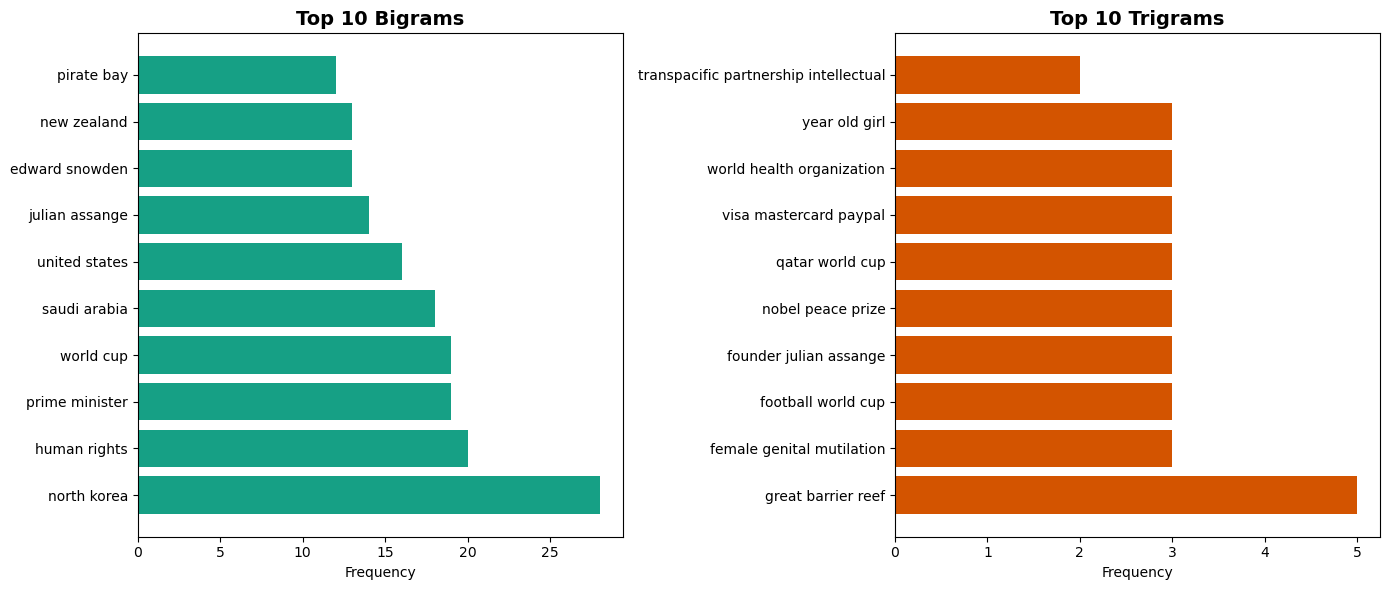

In [25]:
print("\n" + "="*80)
print("ANALYSIS 14: N-gram Analysis (Bigrams & Trigrams)")
print("="*80)

from sklearn.feature_extraction.text import CountVectorizer

def clean_text(text):
    if isinstance(text, bytes):
        text = text.decode('utf-8', errors='ignore')
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['cleaned_text'] = df['Top1'].apply(clean_text)

# Bigrams
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=20, stop_words='english')
bigrams = bigram_vectorizer.fit_transform(df['cleaned_text'])
bigram_freq = dict(zip(bigram_vectorizer.get_feature_names_out(), bigrams.sum(axis=0).A1))
top_bigrams = sorted(bigram_freq.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nTop 10 Bigrams:")
for bigram, freq in top_bigrams:
    print(f"{bigram}: {freq}")

# Trigrams
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3), max_features=20, stop_words='english')
trigrams = trigram_vectorizer.fit_transform(df['cleaned_text'])
trigram_freq = dict(zip(trigram_vectorizer.get_feature_names_out(), trigrams.sum(axis=0).A1))
top_trigrams = sorted(trigram_freq.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nTop 10 Trigrams:")
for trigram, freq in top_trigrams:
    print(f"{trigram}: {freq}")

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
bigram_names, bigram_counts = zip(*top_bigrams)
plt.barh(bigram_names, bigram_counts, color='#16a085')
plt.title('Top 10 Bigrams', fontsize=14, fontweight='bold')
plt.xlabel('Frequency')

plt.subplot(1, 2, 2)
trigram_names, trigram_counts = zip(*top_trigrams)
plt.barh(trigram_names, trigram_counts, color='#d35400')
plt.title('Top 10 Trigrams', fontsize=14, fontweight='bold')
plt.xlabel('Frequency')
plt.tight_layout()
plt.savefig('../plots/analysis_14_ngrams.png', dpi=300, bbox_inches='tight')
plt.show()


### Analysis 14: N-gram Analysis (Bigrams & Trigrams) – Insight
- Frequently occurring bigrams and trigrams reveal common phrase-level patterns in news headlines.
- These multi-word expressions capture more contextual information than single words.
- N-gram features can improve text representation by preserving meaningful word combinations.


### ANALYSIS 15: Feature Correlation Heatmap


ANALYSIS 15: Feature Correlation Heatmap

Correlation Matrix:
                   text_length  special_chars  url_count  positive_keywords  \
text_length           1.000000       0.589515        NaN           0.170074   
special_chars         0.589515       1.000000        NaN           0.121825   
url_count                  NaN            NaN        NaN                NaN   
positive_keywords     0.170074       0.121825        NaN           1.000000   
negative_keywords     0.179363       0.114890        NaN          -0.028819   
Label                -0.022587      -0.030926        NaN          -0.008128   

                   negative_keywords     Label  
text_length                 0.179363 -0.022587  
special_chars               0.114890 -0.030926  
url_count                        NaN       NaN  
positive_keywords          -0.028819 -0.008128  
negative_keywords           1.000000  0.007079  
Label                       0.007079  1.000000  


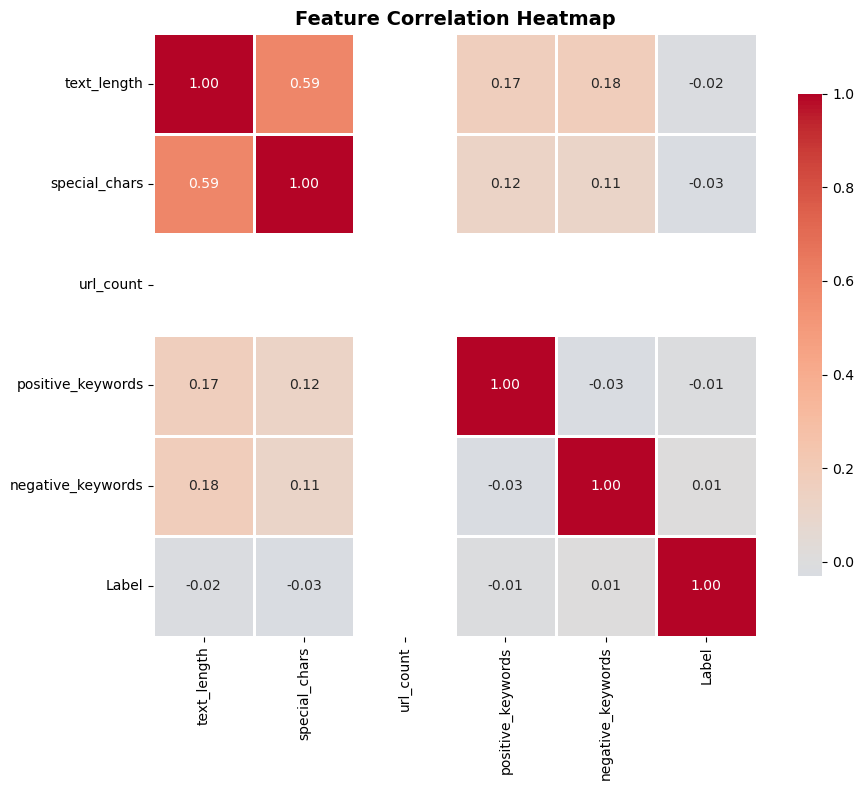

In [26]:
print("\n" + "="*80)
print("ANALYSIS 15: Feature Correlation Heatmap")
print("="*80)

numerical_features = df[['text_length', 'special_chars', 'url_count', 
                          'positive_keywords', 'negative_keywords', 'Label']]

correlation_matrix = numerical_features.corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/analysis_15_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### Analysis 15: Feature Correlation Heatmap – Insight
- Correlation analysis shows weak to moderate relationships between numerical features and the target variable.
- No strong multicollinearity is observed among features.
- The heatmap helps identify potentially informative features while confirming feature independence.
